# Tarefa 3 - Neural Networks Coursework 2026

Third assessed coursework for **Tecnicas e Algoritmos em Ciencia de Dados**.

Write your 6-digit anonymous identifier in the first code cell. Submit a single notebook named with that identifier, for example `568423.ipynb`. Do not submit datasets or extra Python scripts. Any helper function used by your solution must be included in this notebook.

This notebook is a guide. The TODO cells mark the parts you must implement. The TensorFlow baseline cells are provided so you can compare your own implementations against a standard neural-network baseline.

## Overview

1. Regression with neural networks (50%)
2. Multiclass classification with neural networks (50%)

## General rules

- You may use NumPy and basic libraries for matrix operations.
- You must not use library implementations for the algorithms you are asked to implement manually.
- Standardize features manually using only training-set statistics.
- Use the validation set for model selection.
- Use the test set only for final reporting.
- Restart the kernel and run the full notebook before submitting.


In [169]:
student_id = "708024"  # Replace with your 6-digit anonymous identifier.
student_id


'708024'

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import sklearn

np.random.seed(0)


In [171]:
# My Version
print(f"SNS: {sns.__version__}")
print(f"PD: {pd.__version__}")
print(f"NP: {np.__version__}")

SNS: 0.13.2
PD: 3.0.1
NP: 1.26.4


# Helper Functions

Implement any shared helper functions here. In particular, you will need a function to standardize validation and test data using the mean and standard deviation computed from the training set.

Do not use `sklearn.preprocessing.StandardScaler` for this coursework requirement.


In [172]:
import sklearn.metrics


def standardize_from_train(X_train, X_val, X_test, return_mean_std = False):
    """Standardize X_train, X_val, and X_test using training-set statistics only."""
    feature_means = np.mean(X_train, axis= 0)
    feature_std = np.std(X_train, axis= 0)
    feature_std[feature_std == 0] = 1

    X_train = (X_train - feature_means) / feature_std
    X_val = (X_val - feature_means) / feature_std
    X_test = (X_test - feature_means) / feature_std
    
    if return_mean_std:
        return X_train, X_val, X_test, feature_means, feature_std
    
    return X_train, X_val, X_test


def rmse(y_true, y_pred):
    """Return the root mean squared error."""
    return np.sqrt(np.mean((y_true - y_pred)**2))


def one_hot(y, num_classes):
    """Converte labels inteiros em matriz com uns nas classes correspondentes"""
    Y = np.zeros((len(y), num_classes))
    y_normalized = y - y.min()
    Y[np.arange(len(y)), np.array(y_normalized, dtype= int)] = 1
    return Y


def return_labels(y, inicial_class_number: int, map: dict):
    """Retorna do one-hot para os labels iniciais."""
    if y.ndim == 2:
        y_classes = np.array(y.argmax(axis= 1) + inicial_class_number, dtype= object)
        
    for chave, valor in map.items():
        y_classes[y_classes == valor] = chave

    return np.array(y_classes, dtype= str)


def return_classes(y, inicial_class_number: int):
    """Retorna do one-hot para as classes (numeração da classe correspondente)"""
    return np.array(y.argmax(axis= 1) + inicial_class_number, dtype= float)


def multiclass_metrics(y_true_one_hot, predicted_probabilities, predicted_labels):
    """Calcula AUROC, precision, F1, e accuracy para predições multiclasse
    
    Parameters
    ----------
    y_true_one_hot: np.array
        Matriz one_hot com os targets verdadeiros
    predicted_probabilities: np.array
        Matriz de predições de probabilidades
    predicted_labels
        Vetor de classes numeradas preditas
    """
        
    y_true = return_classes(y_true_one_hot, 1) #Vetor de classses target

    auroc     = sklearn.metrics.roc_auc_score(y_true_one_hot, predicted_probabilities, multi_class="ovr")
    precision = sklearn.metrics.precision_score(y_true, predicted_labels, average="macro", zero_division=0)
    f1        = sklearn.metrics.f1_score(y_true, predicted_labels, average="macro", zero_division=0)
    accuracy  = sklearn.metrics.accuracy_score(y_true, predicted_labels)

    print(f"AUROC: {auroc:.4f} | Precision: {precision:.4f} | F1-score: {f1:.4f} | Accuracy: {accuracy:.4f}")
    
    return auroc, precision, f1, accuracy
    

    

# Part 1 - Regression With Neural Networks (50%)

## Dataset

Use `student_performance.csv`. Each row corresponds to a student. The target is `final_score`.

Required preprocessing:

1. Load the dataset.
2. Data cleaning, droping duplicates, and convert categorical variables to numerical variables.
3. Use `final_score` as the regression target.
4. Do not use `student_id` as a feature.
5. Do not use `passed` as a feature because it is derived from the final score.
6. Split the data into training, validation, and test sets using a 70:15:15 ratio.
7. Standardize features manually using only training-set statistics.


In [173]:
raw = pd.read_csv("student_performance.csv")
display(raw.head())
display(raw.describe(include="all"))


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
count,500,500,500.000000,500.000000,500.000000,383,500,500,500.000000,500.000000,500
unique,500,2,NaN,NaN,NaN,4,2,2,NaN,NaN,2
top,STU0001,Female,NaN,NaN,NaN,Master,Yes,No,NaN,NaN,Yes
freq,1,273,NaN,NaN,NaN,100,254,253,NaN,NaN,323
mean,NaN,NaN,16.978000,15.312000,76.380600,NaN,NaN,NaN,62.986000,55.980000,NaN
std,NaN,NaN,1.434445,8.568167,13.817681,NaN,NaN,NaN,18.937451,15.373754,NaN
min,NaN,NaN,15.000000,2.000000,50.200000,NaN,NaN,NaN,30.000000,20.000000,NaN
25%,NaN,NaN,16.000000,8.000000,64.475000,NaN,NaN,NaN,46.000000,45.000000,NaN
50%,NaN,NaN,17.000000,15.000000,76.500000,NaN,NaN,NaN,64.000000,56.000000,NaN
75%,NaN,NaN,18.000000,23.000000,88.525000,NaN,NaN,NaN,79.000000,68.000000,NaN


In [174]:
display(raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 43.1 KB


None

In [175]:
# Antes de falar com Marcelo eu estava usando pd.dropna() para retirar os valores NaN, mas a coluna parent_education possui muitos NaNs,
# Para não perder muita informação do nosso conjunto de dados vamos colocar como "Others"
performance = raw.drop_duplicates()
performance.loc[performance["parent_education"].isna(), "parent_education"] = "Others"
performance.drop(columns= ["student_id", "passed"], inplace= True) #Como nós não vamos utilizar essas colunas, já retirei elas

In [176]:
# Encontrando quais são as varáveis categóricas
for column in performance.columns:
    if performance[column].dtype == "str":
        print(performance[column].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Bachelor', 'High School', 'Master', 'Others', 'PhD']
Length: 5, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [177]:
# Convertendo as variáveis categóricas para variáveis discretas
gender_map = {"Male"  : 1,
              "Female": 2}

parent_education_map = {"Bachelor"    : 1,
                        "High School" : 2,
                        "Master"      : 3,
                        "PhD"         : 4,
                        "Others"      : 5}

internet_acess_map = {"Yes": 1,
                      "No" : 2}

extracurricular_map  = {"Yes": 1,
                    "No" : 2}

performance["gender"] = performance["gender"].map(gender_map)
performance["parent_education"] = performance["parent_education"].map(parent_education_map)
performance["internet_access"] = performance["internet_access"].map(internet_acess_map)
performance["extracurricular"] = performance["extracurricular"].map(extracurricular_map)


In [178]:
X = performance.values[:,:-1]
y = performance.values[:,-1]

In [179]:
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size = 0.7)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, train_size = 0.5)

In [180]:
X_train, X_val, X_test = standardize_from_train(X_train, X_val, X_test)

## NumPy Regression Neural Network

Implement a fully connected neural network using NumPy.

Requirements:

- The number of hidden layers must be configurable. $\textit{FEITO (parâmetro hidden\_layers possibilita isso)}$
- Every hidden layer must have the same number of neurons. $\textit{FEITO (Ao inicializar os parâmetros inicializamos todas as matrizes das hidden layers com mesma dimensão)}$
- Use sigmoid activation functions in hidden layers. $\textit{FEITO (parâmetro hidden\_activation possibilita isso)}$
- Use a linear output layer. $\textit{FEITO (parâmetro output\_activation possibilita isso) }$
- Implement forward propagation manually. $\textit{FEITO}$
- Implement backpropagation manually. $\textit{FEITO}$
- Support three update methods: batch gradient descent, stochastic gradient descent, and mini-batch gradient descent. $\textit{FEITO (É possível escolher o método através de um parâmetro na função fit)}$
- Use early stopping to prevent overfitting. $\textit{FEITO}$
- Track training and validation loss at each epoch. $\textit{FEITO (A função fit retorna uma lista com os valores de cada epoch)}$
- Use learning rate `0.01`. $\textit{FEITO}$
- Train for at most `50` epochs. $\textit{FEITO}$


In [181]:
class ActivationFunction:
    
    def __init__(self, function, derivative = None):
        self.function = function
        self.derivative = derivative
        
def sigmoid(a): return 1/(1 + np.exp(-a))
def sigmoid_prime(a): return sigmoid(a) * (1 - sigmoid(a))

sigmoid_activation = ActivationFunction(sigmoid, sigmoid_prime)

def softmax(a):
    exp_a = np.exp(a)
    return exp_a / exp_a.sum(axis=1, keepdims=True)

def identity(a): return a

In [182]:
class MultilayerPerceptronRegression:

    def __init__(self, hidden_activation: ActivationFunction, output_activation, input_size: int, hidden_layers: int, neurons_per_layer: int, output_size: int = 1):
        """A lista "sizes" deve conter todas as dimensões das camadas da nossa rede, desde a dimensão de entrada
        até a de saída. Tanto os pesos, quanto os biases estarão na matriz de parâmetros."""

        self.num_layers = hidden_layers + 1
        self.num_hidden_layers = hidden_layers
        self.sizes = (input_size, neurons_per_layer, output_size)
        self.hidden_activation = hidden_activation.function
        self.hidden_activation_prime = hidden_activation.derivative
        self.output_activation = output_activation
        self.rng = np.random.default_rng(0)
        self._initialize_parameters()
    

    def _initialize_parameters(self):
        "Inicializa os parâmetros da rede com todas as camadas ocultas com mesmo número de neurônios."
        input_size, hidden_size, output_size = self.sizes
        sizes = [input_size]
        
        for i in range(self.num_hidden_layers):
            sizes.append(hidden_size)
        sizes.append(output_size)
        
        self.parameters = [np.random.randn(y, x + 1) for x,y in zip(sizes[:-1], sizes[1:])]
    

    @staticmethod
    def _add_ones(X):
        """Essa função vai nos permitir adicionar uma coluna de 1s aos nossos dados, para conseguirmos 
        multiplicar pelos biases."""
        return np.column_stack((np.ones(X.shape[0]), X))
    

    def _forward_pass(self, X):
        z = self._add_ones(X)
        Zs = [z]
        As = []
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            a = z @ w.T
            As.append(a)
            
            z = self.hidden_activation(a) 
            z = self._add_ones(z)
            Zs.append(z)

        #Output Layer
        W_output = self.parameters[-1]
        a = z @ W_output.T
        y = self.output_activation(a)

        return y, Zs, As
    

    def _fast_forward_pass(self, X):
        """Realiza o forward_pass sem armazenar os valores necessários para o backpropagation."""
        z = self._add_ones(X)
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            z = self.hidden_activation(z @ w.T) 
            z = self._add_ones(z)

        #Output Layer
        W_output = self.parameters[-1]
        y = self.output_activation(z @ W_output.T)

        return y

    @staticmethod
    def _output_derivative(y_prev, target):
        """Calcula o delta de saída."""
        return y_prev - target
    
    def backpropagation(self, X, y):
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)

        n_out = y_pred.shape[1]
        if n_out == 1:
            y_enc = y.reshape(-1, 1)          

        delta = self._output_derivative(y_pred, y_enc)  
        delta_w[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:])
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w
    
    def compute_loss(self, target, y_pred):
        if y_pred.ndim != target.ndim: y_pred = y_pred.ravel()
        return self.rmse(target, y_pred)
    
    def fit(self, 
            X_train, 
            y_train, 
            X_val,
            y_val,
            update_method = "mini_batch",
            batch_size = 32, 
            lr = 0.01, 
            epochs = 1, 
            patience = 10):
        
        """Treina os parâmetros da nossa rede utilizando o método de mini_batch. Os casos do Stochastic Gradient Descent (SGD)
        e do método batch, são os casos especiais em que batch_size = 1 e batch_size = X.shape[0] (número de data points), respectivamente."""

        if update_method == "sgd": batch_size = 1
        if update_method == "batch": batch_size = X_train.shape[0]
            
        n_samples = X_train.shape[0]
        loss_history_train, loss_history_val = [], [] 
        
        best_val_loss = float('inf')
        best_parameters = [w.copy() for w in self.parameters]
        no_improve = 0

        for epoch in range(epochs):
            idx = np.random.permutation(n_samples)
            X_shuffled, y_shuffled = X_train[idx], y_train[idx] #Isso vai nos permitir pegar os dados em uma sequência aleatória a cada epoch

            for start in range(0, n_samples, batch_size):
                X_batch = X_shuffled[start : start + batch_size]
                y_batch = y_shuffled[start : start + batch_size]

                delta_w = self.backpropagation(X_batch, y_batch)

                for i, dw in enumerate(delta_w):
                    self.parameters[i] -= lr * dw

            y_pred_train = self._fast_forward_pass(X_train)
            y_pred_val = self._fast_forward_pass(X_val)
            loss_history_train.append(self.compute_loss(y_train, y_pred_train))
            loss_history_val.append(self.compute_loss(y_val, y_pred_val))
            
            #Aplicação do Early Stopping
            if loss_history_val[-1] < best_val_loss:
                best_val_loss  = loss_history_val[-1]
                best_parameters = [w.copy() for w in self.parameters]
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    self.parameters = best_parameters 
                    break

        return loss_history_train, loss_history_val
    
    def predict(self, X):
        y_pred = self._fast_forward_pass(X)
        
        if y_pred.shape[1] == 1:
            y_pred = y_pred.flatten()
            
        return y_pred
    
    @staticmethod
    def sse(target, y_prev): return np.sum((target - y_prev)**2) * 0.5

    @staticmethod
    def rmse(target, y_prev): return np.sqrt(np.mean((target - y_prev)**2))

## Regression Hyperparameter Tuning

Choose:

- 3 values for number of hidden layers, for example `[1, 2, 3]`.
- 3 values for neurons per hidden layer, for example `[100, 150, 250]`.
- The 3 update methods: batch GD, SGD, and mini-batch GD.

For each combination, train the model and record the validation RMSE. This gives 27 validation results.


In [183]:
np.random.seed(0)

regression_hidden_layers = [1, 2, 3]
regression_neurons = [100, 150, 250]
regression_update_methods = ["batch", "sgd", "mini_batch"]
regression_learning_rate = 0.01
regression_epochs = 50
regression_patience = 10

results = []

for hidden_layers in regression_hidden_layers:
    for neurons_per_layer in regression_neurons:
        for update_method in regression_update_methods:
            MLP = MultilayerPerceptronRegression(hidden_activation= sigmoid_activation, 
                                                output_activation= identity, 
                                                input_size= 8, 
                                                hidden_layers= hidden_layers, 
                                                neurons_per_layer= neurons_per_layer)
            
            loss_train, loss_val = MLP.fit(X_train, y_train, X_val, y_val, update_method= update_method, batch_size= 32, lr= regression_learning_rate, epochs= regression_epochs, patience= regression_patience)
            min_loss_val = min(loss_val)
            
            results.append({"update_method": update_method,
                            "hidden_layers": hidden_layers,
                            "neurons_per_layer": neurons_per_layer,
                            "validation_rmse": min_loss_val,
                            "best_epoch": loss_val.index(min_loss_val) + 1,
                            "stopped_epoch": len(loss_val)})
            
            
regression_results = pd.DataFrame(results).sort_values("validation_rmse", inplace= False).reset_index()
display(regression_results)

,index,update_method,hidden_layers,neurons_per_layer,validation_rmse,best_epoch,stopped_epoch
0,2,mini_batch,1,100,7.277780,12,22
1,5,mini_batch,1,150,7.305267,19,29
2,8,mini_batch,1,250,7.421089,14,24
3,6,batch,1,250,7.636908,50,50
4,3,batch,1,150,7.686180,50,50
5,15,batch,2,250,7.779998,50,50
6,12,batch,2,150,7.797091,50,50
7,1,sgd,1,100,7.841961,1,11
8,11,mini_batch,2,100,7.853992,12,22
9,20,mini_batch,3,100,7.880499,10,20


,index,update_method,hidden_layers,neurons_per_layer,validation_rmse,best_epoch,stopped_epoch
0,2,mini_batch,1,100,7.27778,12,22


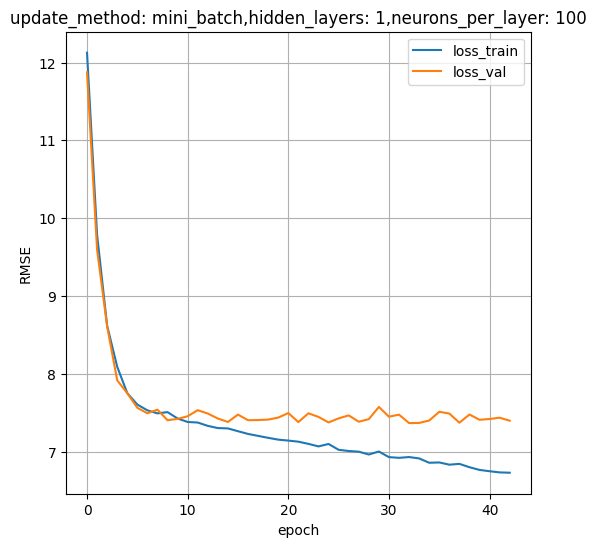

In [184]:
display(regression_results.head(1))

MLP = MultilayerPerceptronRegression(hidden_activation= sigmoid_activation, 
                                                output_activation= identity, 
                                                input_size= 8, 
                                                hidden_layers= regression_results["hidden_layers"][0], 
                                                neurons_per_layer= regression_results["neurons_per_layer"][0])
            
loss_train, loss_val = MLP.fit(X_train, y_train, X_val, y_val, update_method= regression_results["update_method"][0] , lr= regression_learning_rate, epochs= 50, patience= 10)

fig = plt.figure(figsize= (6,6))
plt.plot(loss_train, label= "loss_train")
plt.plot(loss_val, label= "loss_val")

plt.grid()
plt.legend()

plt.title(f"update_method: {regression_results['update_method'][0]},"
        f"hidden_layers: {regression_results['hidden_layers'][0]},"
        f"neurons_per_layer: {regression_results['neurons_per_layer'][0]}")

plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.show()

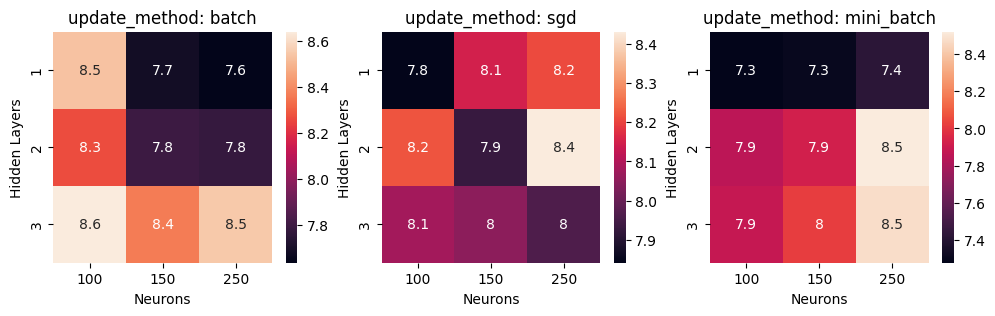

In [185]:
fig, axes = plt.subplots(1, 3, figsize= (12, 3))

for ax, update_method in zip(axes, regression_update_methods):
    raw = regression_results[regression_results["update_method"] == update_method][["neurons_per_layer", "hidden_layers", "validation_rmse"]].sort_values(["hidden_layers", "neurons_per_layer"])
    data = raw.values[:,-1].reshape((3,3))
    
    sns.heatmap(data, annot= True, xticklabels= regression_neurons, yticklabels= regression_hidden_layers, ax= ax)
    ax.set_title(f"update_method: {update_method}")
    ax.set_ylabel("Hidden Layers")
    ax.set_xlabel("Neurons")

plt.show()
    

In [186]:
best_hidden_layers = regression_results['hidden_layers'][0]
best_neurons = regression_results['neurons_per_layer'][0]

y_pred_val = MLP.predict(X_val)
best_regression_validation_rmse = MLP.rmse(y_val, y_pred_val)
y_pred_test = MLP.predict(X_test)
best_regression_test_rmse = MLP.rmse(y_test, y_pred_test)

print(f"------------- RMSE ---------------")
print(f"Validation: {best_regression_validation_rmse}")
print(f"Test: {best_regression_test_rmse}")


------------- RMSE ---------------
Validation: 7.3654017893481925
Test: 8.056887511044346


## Scratch Linear Regression Baseline

Use your own linear regression implementation from previous labs or courseworks. Train it on the same training set and evaluate it on the same test set.


In [187]:
class ScratchLinearRegression:
    
    def __init__(self):
        self.parameters = None
        
    @staticmethod
    def _add_ones(X):
        """Essa função vai nos permitir adicionar uma coluna de 1s aos nossos dados, para conseguirmos 
        multiplicar pelos biases."""
        return np.column_stack((np.ones(X.shape[0]), X))
    
    def fit(self, X, y, epochs= 5000 , learning_rate=0.01):
        """
        Implements a Linear Regression model using Stochastic Gradient Descent
        
        Parameters
        ----------
        X : array
            A 2-dimensional array with samples in the rows and features in the columns
        y : array
            An array with the same number of  as samples in X, the values to predict
        lr : float
            Learning rate
        max_iter : int
            number of epochs to use for the gradient descent
        
        Returns
        -------
        w : array
            Learnt parameters
        sse_history : array
            An array that contains the error of the model in every iteration
        Notes
        -----
        This function uses the gradient of the sum of squares function (Equations 3.12, and 3.23 in the Bishop book)
        """
        
        
        Phi = self._add_ones(X)
        
        n_samples, n_features = Phi.shape
        w = np.random.normal(0, 1, size=n_features)
        sse_history = []
        
        for i in range(epochs):
            sse_ = 0
            
            for j in range(Phi.shape[0]):
                sse = (1/2) * (y[j] - w @ Phi[j])**2
                sse_ += sse
                
                w_t1 = w + learning_rate * (y[j] - w @ Phi[j]) * Phi[j]
                w = w_t1
                
            sse_history.append(sse_)
            
        self.parameters = w
        return sse_history


    def predict(self, X):
        if self.parameters is not None: 
            return self._add_ones(X) @ self.parameters
        else:
            print("Primeiro realize o fit.")
        
        
        


In [188]:
LinearRegression = ScratchLinearRegression()
LinearRegression.fit(X_train, y_train)
y_pred_val_lr = LinearRegression.predict(X_val)
y_pred_test_lr = LinearRegression.predict(X_test)

rmse_val_lr = rmse(y_val, y_pred_val_lr)
rmse_test_lr = rmse(y_test, y_pred_test_lr)
     
print(f"------------- RMSE ---------------")
print(f"Validation: {rmse_val_lr}")
print(f"Validation: {rmse_test_lr}")

------------- RMSE ---------------
Validation: 7.35318403988982
Validation: 7.590779015862527


## TensorFlow Regression Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `best_hidden_layers`, and `best_neurons`.


In [189]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_hidden_layers" not in globals() or "best_neurons" not in globals():
    raise NameError("Define best_hidden_layers and best_neurons from your validation search before running this cell.")

regression_patience = globals().get("regression_patience", 10)
regression_epochs = globals().get("regression_epochs", 50)
regression_learning_rate = globals().get("regression_learning_rate", 0.01)

tf_regression_model = tf.keras.Sequential()
tf_regression_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for _ in range(int(best_hidden_layers)):
    tf_regression_model.add(tf.keras.layers.Dense(int(best_neurons), activation="sigmoid"))
tf_regression_model.add(tf.keras.layers.Dense(1, activation="linear"))

tf_regression_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=regression_learning_rate),
    loss="mse",
)

tf_regression_history = tf_regression_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=regression_epochs,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=regression_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_regression_val_predictions = tf_regression_model.predict(X_val, verbose=0)
tf_regression_test_predictions = tf_regression_model.predict(X_test, verbose=0)

tf_regression_results = pd.DataFrame([
    {
        "model": "TensorFlow regression baseline",
        "hidden_layers": int(best_hidden_layers),
        "neurons_per_layer": int(best_neurons),
        "validation_rmse": float(np.sqrt(np.mean((y_val - tf_regression_val_predictions) ** 2))),
        "test_rmse": float(np.sqrt(np.mean((y_test - tf_regression_test_predictions) ** 2))),
        "epochs_trained": len(tf_regression_history.history["loss"]),
    }
])

display(tf_regression_results)


,model,hidden_layers,neurons_per_layer,validation_rmse,test_rmse,epochs_trained
0,TensorFlow regression baseline,1,100,20.066082,21.97627,15


In [190]:
final_results = {"Model": ["Multilayer Perceptron", "Scratch Linear Regression", "TensorFlow baseline"], "RMSE test_set": [best_regression_test_rmse, rmse_test_lr, tf_regression_results["test_rmse"].values[0]]}
df_final_results = pd.DataFrame(final_results)
display(df_final_results)

,Model,RMSE test_set
0,Multilayer Perceptron,8.056888
1,Scratch Linear Regression,7.590779
2,TensorFlow baseline,21.976270


# Part 2 - Multiclass Classification With Neural Networks (50%)

## Dataset

Use `dry_bean_database.csv`. Each row is one bean described by 16 numerical features. The target column is `Class`, with 7 mutually exclusive classes.

Required preprocessing:

1. Load the dataset.
2. Remove duplicated rows.
3. Convert numeric feature columns when needed. Some copies may store decimal values as strings with comma separators.
4. Encode `Class` as a multiclass target.
5. Split into training, validation, and test sets using a 70:15:15 ratio. Use stratification.
6. Standardize features manually using only training-set statistics.


In [191]:
raw = pd.read_csv("dry_bean_database.csv", decimal=",")
display(raw.head())
display(raw.describe(include="all"))


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DERMASON
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3546
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063,NaN
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366,NaN
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687,NaN
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703,NaN
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386,NaN
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883,NaN


In [192]:
dry_beans = raw.drop_duplicates()
dry_beans.info()

<class 'pandas.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  str    
dtypes: float64(14), int64(2), st

In [193]:
class_map = {'SEKER': 1, 'BARBUNYA': 2, 'BOMBAY': 3, 'CALI': 4, 'HOROZ': 5, 'SIRA': 6, 'DERMASON': 7}

dry_beans["Class"] = dry_beans["Class"].map(class_map)

In [194]:
for column in dry_beans.columns[:-1]:
    if dry_beans[column].dtype == "int64":
        dry_beans[column] = dry_beans[column].astype(float)

In [195]:
X = dry_beans.values[:,:-1]
y = dry_beans.values[:,-1]

In [196]:
y = one_hot(y, 7)
class_labels = return_classes(y, inicial_class_number= 1)

In [197]:
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size= 0.7)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, train_size= 0.5)
labels_train, labels_val, labels_test = return_classes(y_train, 1), return_classes(y_val, 1), return_classes(y_test, 1)

X_train, X_val, X_test = standardize_from_train(X_train, X_val, X_test)

## NumPy Multiclass Neural Network

Implement a fully connected multiclass classifier using NumPy.

Requirements:

- The architecture must accept a list of hidden-layer sizes, for example `[64, 128, 256]`.
- Use sigmoid activation functions in hidden layers.
- Use softmax in the output layer.
- Use multiclass cross-entropy loss.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support batch GD, SGD, and mini-batch GD.
- Use early stopping.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `1000` epochs.


In [198]:
class MultilayerPerceptronClassification:

    def __init__(self, hidden_activation: ActivationFunction, output_activation, input_size: int, hidden_sizes: list, output_size: int):
        """A lista "sizes" deve conter todos as dimensões das hidden layers da nossa rede."""

        # Número de camadas
        self.num_layers = len(hidden_sizes) + 1
        self.num_hidden_layers = len(hidden_sizes)
        
        #Dimesões das camdas
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        
        #Funções que precisaremos
        self.hidden_activation = hidden_activation.function
        self.hidden_activation_prime = hidden_activation.derivative
        self.output_activation = output_activation
        
        #Inicialização dos parâmetros
        self._initialize_parameters()
    

    def _initialize_parameters(self):
        sizes = [self.input_size]
        
        for hidden_size in self.hidden_sizes:
            sizes.append(hidden_size)
        sizes.append(self.output_size)
        
        self.parameters = [np.random.randn(y, x + 1) for x,y in zip(sizes[:-1], sizes[1:])]
    

    @staticmethod
    def _add_ones(X):
        """Essa função vai nos permitir adicionar uma coluna de 1s aos nossos dados, para conseguirmos 
        multiplicar pelos biases."""
        return np.column_stack((np.ones(X.shape[0]), X))
    
    @staticmethod
    def _one_hot(y, num_classes):
        """Converte labels inteiros em matriz com uns nas classes correspondentes"""
        Y = np.zeros((len(y), num_classes))
        y_normalized = y - y.min()
        Y[np.arange(len(y)), np.array(y_normalized, dtype= int)] = 1
        return Y
    
    def _forward_pass(self, X):
        z = self._add_ones(X)
        Zs = [z]
        As = []
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            a = z @ w.T
            As.append(a)
            
            z = self.hidden_activation(a) 
            z = self._add_ones(z)
            Zs.append(z)

        #Output Layer
        W_output = self.parameters[-1]
        a = z @ W_output.T
        y = self.output_activation(a)

        return y, Zs, As
    

    def _fast_forward_pass(self, X):
        """Realiza o forward_pass sem ficar armazendo os valores necessários para o backpropagation."""
        z = self._add_ones(X)
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            a = z @ w.T
            
            z = self.hidden_activation(a) 
            z = self._add_ones(z)

        #Output Layer
        W_output = self.parameters[-1]
        a = z @ W_output.T
        y = self.output_activation(a)

        return y
        

    @staticmethod
    def _output_derivative(y_prev, target):
        """Calcula o delta de saída."""
        return y_prev - target
    
    def backpropagation(self, X, y):
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)

        if y.ndim == 1:
            y_target  = self._one_hot(y, self.output_size) 
        else:
            y_target = y        

        delta = self._output_derivative(y_pred, y_target)  
        delta_w[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:]) 
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w
    
    
    def compute_loss(self, target, y_pred):
        return self.cross_entropy_multiclass(target, y_pred)
    
    def fit(self, 
            X_train, 
            y_train, 
            X_val,
            y_val,
            update_method = "mini_batch",
            batch_size = 32, 
            lr = 0.01, 
            epochs=1, 
            weight_decay = 0.0,
            patience = 10):
        
        """Treina os parâmetros da nossa rede utilizando o método de mini_batch. Os casos do Stochastic Gradient Descent (SGD)
        e do método batch, são os casos especiais em que batch_size = 1 e batch_size = X.shape[0] (número de data points), respectivamente."""

        if update_method == "sgd": batch_size = 1
        if update_method == "batch": batch_size = X_train.shape[0]
            
        n_samples = X_train.shape[0]
        loss_history_train, loss_history_val = [], [] 
        
        best_val_loss = float('inf')
        best_parameters = [w.copy() for w in self.parameters]
        no_improve = 0

        for epoch in range(epochs):
            idx = np.random.permutation(n_samples)
            X_shuffled, y_shuffled = X_train[idx], y_train[idx] #Isso vai nos permitir pegar os dados em uma sequência aleatória a cada epoch

            for start in range(0, n_samples, batch_size):
                X_batch = X_shuffled[start : start + batch_size]
                y_batch = y_shuffled[start : start + batch_size]

                delta_w = self.backpropagation(X_batch, y_batch)

                for i, dw in enumerate(delta_w):
                    
                    #Aplicação do Weigth Decay
                    if weight_decay > 0:
                        regularization = np.zeros_like(self.parameters[i])
                        regularization[:, 1:] = weight_decay * self.parameters[i][:, 1:] 
                        dw = dw + regularization
                    
                    self.parameters[i] -= lr * dw

            y_pred_train = self._fast_forward_pass(X_train)
            y_pred_val = self._fast_forward_pass(X_val)
            loss_history_train.append(self.compute_loss(y_train, y_pred_train))
            loss_history_val.append(self.compute_loss(y_val, y_pred_val))
            
            #Aplicação do Early Stopping
            if loss_history_val[-1] < best_val_loss:
                best_val_loss  = loss_history_val[-1]
                best_parameters = [w.copy() for w in self.parameters]
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    self.parameters = best_parameters 
                    break

        return loss_history_train, loss_history_val
    
    def predict(self, X):
        return self._fast_forward_pass(X)
    
    def predict_classes(self, X, initial_class: int):
        """Retorna o índice da classe com maior probabilidade."""
        y_pred = self._fast_forward_pass(X)
        return np.argmax(y_pred, axis=1) + initial_class
    
    def cross_entropy_multiclass(self, target, y_pred):
        if target.ndim == 1:
            t = self._one_hot(target, self.output_size)
        else:
            t = target
            
        n = len(target)
        return - np.sum(t * np.log(y_pred)) / n 

## Classification Hyperparameter Tuning

Choose 3 hidden-layer configurations. The number of neurons does not need to be the same in every layer for this part.

For each update method, train the 3 architectures and record the validation loss. This gives 9 validation results.


In [199]:
classification_layer_configs = [
    [64],
    [128, 64],
    [128, 128, 64],
]
classification_update_methods = ["batch", "sgd", "mini_batch"]
classification_learning_rate = 0.01
classification_epochs = 300
classification_patience = 50

results = []

for architeture in classification_layer_configs:
    for update_method in classification_update_methods:
            MLP = MultilayerPerceptronClassification(hidden_activation= sigmoid_activation, 
                                                    output_activation= softmax, 
                                                    input_size= 16,
                                                    hidden_sizes= architeture,
                                                    output_size= 7)
            
            loss_train, loss_val = MLP.fit(X_train, y_train, X_val, y_val, update_method= update_method, batch_size= 32, lr= classification_learning_rate, epochs= classification_epochs, patience= classification_patience)
            min_loss_val = min(loss_val)
            
            print(({"update_method": update_method,
                            "architeture": architeture,
                            "validation_loss": min_loss_val,
                            "best_epoch": loss_val.index(min_loss_val) + 1,
                            "stopped_epoch": len(loss_val)}))
            
            results.append({"update_method": update_method,
                            "architeture": architeture,
                            "n_layers": len(architeture),
                            "validation_loss": min_loss_val,
                            "best_epoch": loss_val.index(min_loss_val) + 1,
                            "stopped_epoch": len(loss_val)})
            
            
classification_results = pd.DataFrame(results).sort_values("validation_loss", inplace= False).reset_index()
display(classification_results)

{'update_method': 'batch', 'architeture': [64], 'validation_loss': 1.2338280467045544, 'best_epoch': 300, 'stopped_epoch': 300}
{'update_method': 'sgd', 'architeture': [64], 'validation_loss': 0.17045250441691034, 'best_epoch': 57, 'stopped_epoch': 107}
{'update_method': 'mini_batch', 'architeture': [64], 'validation_loss': 0.1776844454960204, 'best_epoch': 299, 'stopped_epoch': 300}
{'update_method': 'batch', 'architeture': [128, 64], 'validation_loss': 0.7159948804693675, 'best_epoch': 300, 'stopped_epoch': 300}
{'update_method': 'sgd', 'architeture': [128, 64], 'validation_loss': 0.17080509573175934, 'best_epoch': 24, 'stopped_epoch': 74}
{'update_method': 'mini_batch', 'architeture': [128, 64], 'validation_loss': 0.17742604161221895, 'best_epoch': 299, 'stopped_epoch': 300}
{'update_method': 'batch', 'architeture': [128, 128, 64], 'validation_loss': 0.9780035316160638, 'best_epoch': 300, 'stopped_epoch': 300}
{'update_method': 'sgd', 'architeture': [128, 128, 64], 'validation_loss'

,index,update_method,architeture,n_layers,validation_loss,best_epoch,stopped_epoch
0,1,sgd,[64],1,0.170453,57,107
1,4,sgd,"[128, 64]",2,0.170805,24,74
2,5,mini_batch,"[128, 64]",2,0.177426,299,300
3,2,mini_batch,[64],1,0.177684,299,300
4,7,sgd,"[128, 128, 64]",3,0.177939,19,69
5,8,mini_batch,"[128, 128, 64]",3,0.180973,298,300
6,3,batch,"[128, 64]",2,0.715995,300,300
7,6,batch,"[128, 128, 64]",3,0.978004,300,300
8,0,batch,[64],1,1.233828,300,300


In [200]:
display(classification_results.head(1))

MLP = MultilayerPerceptronClassification(hidden_activation= sigmoid_activation, 
                                                output_activation= softmax, 
                                                input_size= 16, 
                                                hidden_sizes= classification_results["architeture"][0], 
                                                output_size= 7)
            
loss_train, loss_val = MLP.fit(X_train, y_train, X_val, y_val, update_method= classification_results["update_method"][0] , lr= classification_learning_rate, epochs= classification_epochs, patience= classification_patience)

,index,update_method,architeture,n_layers,validation_loss,best_epoch,stopped_epoch
0,1,sgd,[64],1,0.170453,57,107


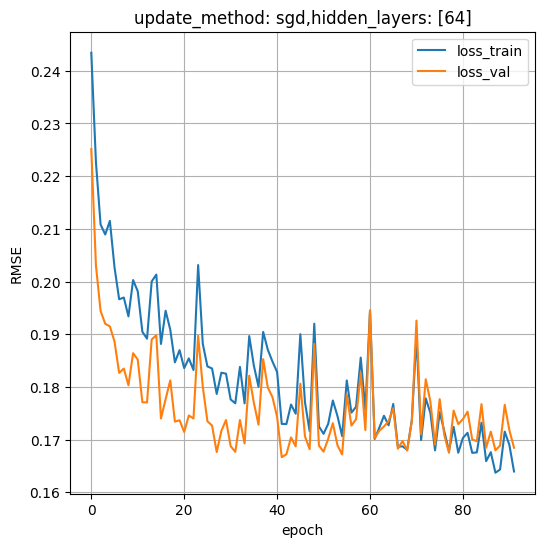

In [201]:
fig = plt.figure(figsize= (6,6))
plt.plot(loss_train, label= "loss_train")
plt.plot(loss_val, label= "loss_val")

plt.grid()
plt.legend()

plt.title(f"update_method: {classification_results['update_method'][0]},"
            f"hidden_layers: {classification_results['architeture'][0]}")

plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.show()

In [202]:
classification_results["architeture_labels"] = classification_results["architeture"].astype(str)

In [203]:
classification_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               9 non-null      int64  
 1   update_method       9 non-null      str    
 2   architeture         9 non-null      object 
 3   n_layers            9 non-null      int64  
 4   validation_loss     9 non-null      float64
 5   best_epoch          9 non-null      int64  
 6   stopped_epoch       9 non-null      int64  
 7   architeture_labels  9 non-null      str    
dtypes: float64(1), int64(4), object(1), str(2)
memory usage: 708.0+ bytes


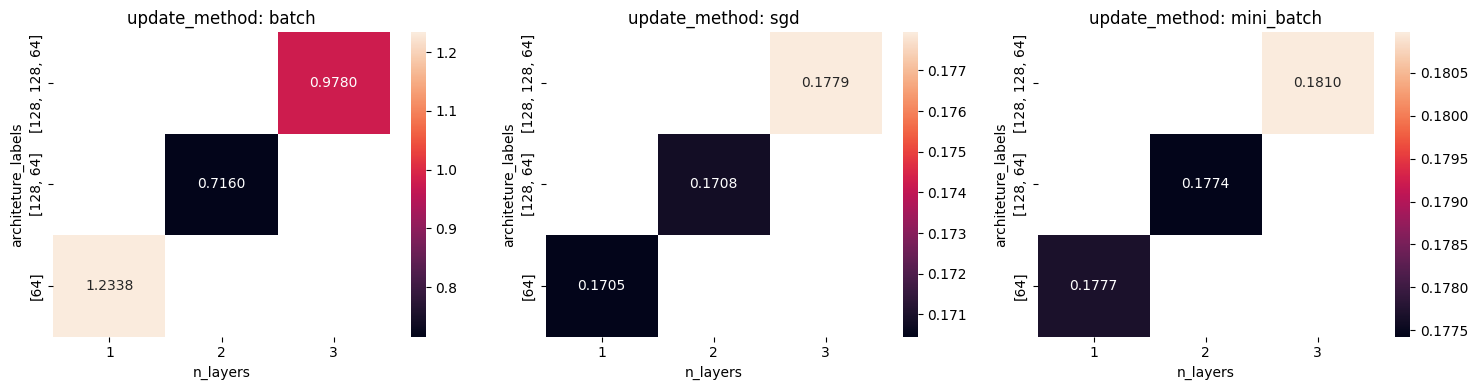

In [204]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, method in zip(axes, ["batch", "sgd", "mini_batch"]):
    subset = classification_results[classification_results["update_method"] == method]
    
    pivot = subset.pivot(
        index="architeture_labels",
        columns="n_layers",
        values="validation_loss"
    )
    
    sns.heatmap(data=pivot, annot=True, fmt=".4f", ax=ax)
    ax.set_title(f"update_method: {method}")

plt.tight_layout()
plt.show()

In [205]:
best_classification_layers = classification_results['architeture'][0]

MLP = MultilayerPerceptronClassification(hidden_activation= sigmoid_activation, 
                                                output_activation= softmax, 
                                                input_size= 16, 
                                                hidden_sizes= best_classification_layers, 
                                                output_size= 7)
            
loss_train, loss_val = MLP.fit(X_train, y_train, X_val, y_val, update_method= classification_results["update_method"][0] , lr= classification_learning_rate, epochs= classification_epochs, patience= classification_patience)
y_pred = MLP.predict(X_test)
y_pred_classes = MLP.predict_classes(X_test, 1)

mlp_auroc, mlp_precision, mlp_f1, mlp_accuracy = multiclass_metrics(y_test, y_pred, y_pred_classes)

AUROC: 0.9959 | Precision: 0.9434 | F1-score: 0.9431 | Accuracy: 0.9336


## Scratch Logistic Regression Baseline

Use your own logistic regression implementation from previous labs or courseworks. For this multiclass dataset, you may implement one-vs-rest logistic regression or softmax regression.


In [206]:
def CrossEntropy(target, predicted):
    result = - np.sum(target * np.log(predicted + 1e-10) + (1 - target) * np.log(1 - predicted + 1e-10))
    return result

class ScratchLogisticRegression:
    
    @staticmethod
    def _add_ones(X):
        """Essa função vai nos permitir adicionar uma coluna de 1s aos nossos dados, para conseguirmos 
        multiplicar pelos biases."""
        return np.column_stack((np.ones(X.shape[0]), X))
    
    def cross_entropy_multiclass(self, target, y_pred):
        if target.ndim == 1:
            t = self._one_hot(target, self.output_size)
        else:
            t = target
            
        n = len(target)
        return - np.sum(t * np.log(y_pred)) / n 
    
    def SthocasticGradientDescendent(self, X, y, lr, max_iter):
        X_b = self._add_ones(X)  
        n_sample, n_features = X_b.shape
        np.random.seed(0)
        
        n_classes = y.shape[1]
        w = np.random.normal(scale=0.1, size=(n_features, n_classes))
        error_historic = []

        for i in range(max_iter):
            for j in range(n_sample):
                x_j = X_b[j].reshape(-1, 1)                              
                delta = softmax(X_b[j].reshape(1, -1) @ w) - y[j].reshape(1, -1)  
                w = w - lr * (x_j @ delta)     

            ce = self.cross_entropy_multiclass(y, softmax(X_b @ w)) 
            error_historic.append(ce)

        self.parameters = w
        return w, error_historic
    
    def predict_proba(self, X):
        X_ = self._add_ones(X)
        y_prob = softmax(X_ @ self.parameters)
        return y_prob

    def predict_classes(self, X, initial_class: int):
        """Retorna o índice da classe com maior probabilidade."""
        y_pred = self.predict_proba(X)
        return np.argmax(y_pred, axis=1) + initial_class
        


In [207]:
LogRegression = ScratchLogisticRegression()
w_trained, loss_history = LogRegression.SthocasticGradientDescendent(X_train, y_train, 0.01, 1000)
y_pred = LogRegression.predict_proba(X_test)
y_pred_classes = LogRegression.predict_classes(X_test, 1)

In [208]:
print(f"Cross Entropy: {LogRegression.cross_entropy_multiclass(y_test, y_pred)}")

Cross Entropy: 0.19783917565526316


In [209]:
lr_auroc, lr_precision, lr_f1, lr_accuracy = multiclass_metrics(y_test, y_pred, y_pred_classes)

AUROC: 0.9955 | Precision: 0.9358 | F1-score: 0.9347 | Accuracy: 0.9227


## TensorFlow Classification Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `class_names`, and `best_classification_layers`.


In [210]:
import tensorflow as tf
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, accuracy_score

tf.random.set_seed(0)

if "best_classification_layers" not in globals():
    raise NameError("Define best_classification_layers from your validation search before running this cell.")

classification_patience = globals().get("classification_patience", 50)
classification_epochs = globals().get("classification_epochs", 1000)
classification_learning_rate = globals().get("classification_learning_rate", 0.01)

tf_classification_model = tf.keras.Sequential()
tf_classification_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for units in best_classification_layers:
    tf_classification_model.add(tf.keras.layers.Dense(int(units), activation="sigmoid"))
tf_classification_model.add(tf.keras.layers.Dense(y_train.shape[1], activation="softmax"))

tf_classification_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=classification_learning_rate),
    loss="categorical_crossentropy",
)

tf_classification_history = tf_classification_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=classification_epochs,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=classification_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_classification_probabilities = tf_classification_model.predict(X_test, verbose=0)
tf_classification_predictions = np.argmax(tf_classification_probabilities, axis=1)
tf_true_labels = np.argmax(y_test, axis=1)

tf_precision, tf_recall, tf_f1, _ = precision_recall_fscore_support(
    tf_true_labels,
    tf_classification_predictions,
    average="macro",
    zero_division=0,
)

tf_auroc = roc_auc_score(y_test, tf_classification_probabilities, average="macro")
tf_accuracy = accuracy_score(tf_true_labels, tf_classification_predictions)

tf_classification_results = pd.DataFrame([
    {
        "model": "TensorFlow classification baseline",
        "architecture": str(list(best_classification_layers)),
        "test_macro_ovr_auroc": tf_auroc,
        "test_accuracy": tf_accuracy,
        "test_macro_precision": tf_precision,
        "test_macro_recall": tf_recall,
        "test_macro_f1": tf_f1,
        "epochs_trained": len(tf_classification_history.history["loss"]),
    }
])

display(tf_classification_results)


,model,architecture,test_macro_ovr_auroc,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,epochs_trained
0,TensorFlow classification baseline,[64],0.99446,0.918307,0.932111,0.930415,0.93108,300


In [211]:
comparison_cls = pd.DataFrame([
    {'Modelo': 'Multilayer Perceptron',              'AUROC': mlp_auroc,  'Precisão': mlp_precision,  'F1': mlp_f1,  'Acurácia': mlp_accuracy},
    {'Modelo': 'Scratch Logistic Regression',    'AUROC': lr_auroc,  'Precisão': lr_precision,  'F1': lr_f1,  'Acurácia': lr_accuracy},
    {'Modelo': 'TensorFlow baseline',  'AUROC': tf_auroc,  'Precisão': tf_precision,  'F1': tf_f1,  'Acurácia': tf_accuracy},
])
display(comparison_cls.style.format({
    'AUROC': '{:.4f}', 'Precisão': '{:.4f}', 'F1': '{:.4f}', 'Acurácia': '{:.4f}'
}))

,Modelo,AUROC,Precisão,F1,Acurácia
0,Multilayer Perceptron,0.9959,0.9434,0.9431,0.9336
1,Scratch Logistic Regression,0.9955,0.9358,0.9347,0.9227
2,TensorFlow baseline,0.9945,0.9321,0.9311,0.9183


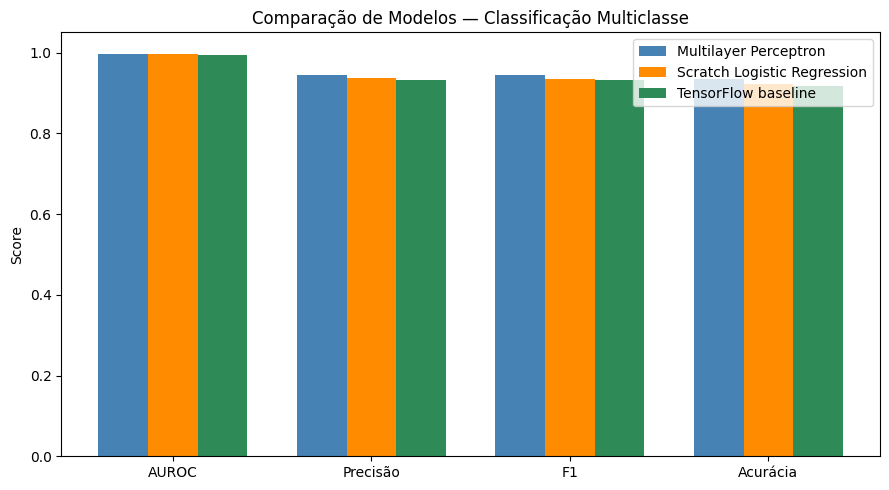

In [212]:
metrics = ['AUROC', 'Precisão', 'F1', 'Acurácia']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (_, row) in enumerate(comparison_cls.iterrows()):
    ax.bar(x + i * width,
           [row[m] for m in metrics],
           width, label=row['Modelo'], color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — Classificação Multiclasse')
ax.legend()
plt.tight_layout()
plt.show()

# Apêndice

## 1. Relembrando métodos de atualização

### Método de Stochastic Gradient Descent

The stochastic process { wt, t= 1, . . . } depends on the examples $\textbf{RANDOMLY
PICKED AT EACH ITERATION.}$



$\textit{Large-Scale Machine Learning with Stochastic Gradient Descent, Bottou (2010); Referenciado pelo Bishop em Deep Learning: Foudantions and Concepts p. 215}$


### Método de mini-batch

Another consideration in choosing the
mini-batch size is the desire to make efficient use of the hardware architecture on
which the code is running. For example, on some hardware platforms, mini-batch
sizes that are powers of 2 (for example, 64, 128, 256, ...) work well.

One important consideration when using mini-batches is that $\textbf{THE CONSTITUENT DATA
POINTS SHOULD BE CHOSEN RANDOMLY FROM THE DATA SET}$, since in raw data sets there
may be correlations between successive data points arising from the way the data
was collected (for example, if the data points have been ordered alphabetically or
by date). This is often handled by randomly shuffling the entire data set and then
subsequently drawing mini-batches as successive blocks of data. The data set can
also be reshuffled between iterations through the data set, so that each mini-batch is
unlikely to have been used before, which can help escape local minima. The variant
of stochastic gradient descent with mini-batches is summarized in Algorithm 7.2.
Note that the learning algorithm is often still called ‘stochastic gradient descent’
even when mini-batches are used.

$\textit{Deep Learning: Foudantions and Concepts p. 216}$

